<a href="https://colab.research.google.com/github/Kenny625819/Applied-Data-Science/blob/main/DHS_submit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Please upload the Excel file named 'DHS data.xlsx'.


Saving DHS data.xlsx to DHS data (3).xlsx

Uploaded file: DHS data (3).xlsx

Data-quality check
------------------
Rows before duplicate removal: 155
Rows after duplicate removal:  155
Records removed:               0

Final analytic cohort
---------------------
DHS: 35
CSM: 120
Total: 155


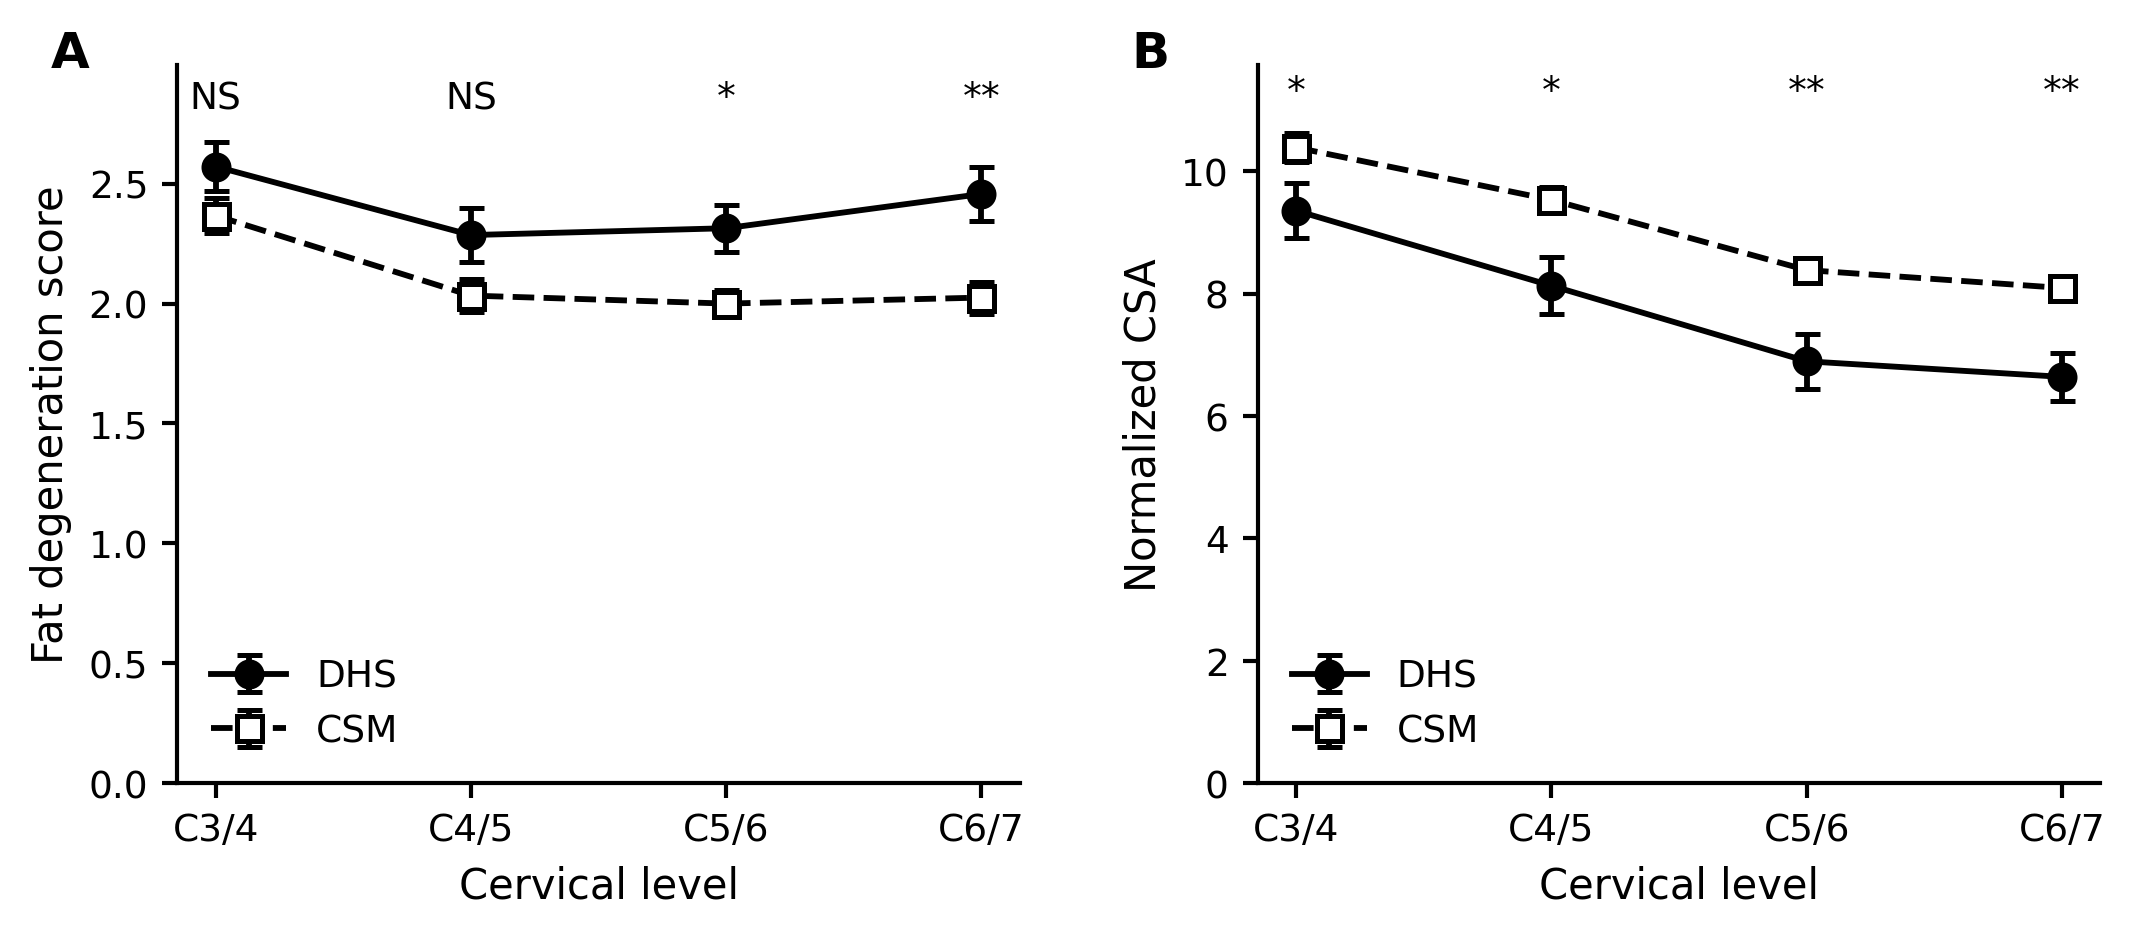


Level-specific comparison results
---------------------------------


,level,dhs_normalized_csa_mean,csm_normalized_csa_mean,csa_raw_p,csa_fdr_p,csa_fdr_significance,dhs_fat_mean,csm_fat_mean,fat_raw_p,fat_fdr_p,fat_fdr_significance
0,C3/4,9.3593,10.3909,0.0471,0.0471,*,2.5714,2.3667,0.1402,0.1402,NS
1,C4/5,8.1319,9.5352,0.0085,0.0113,*,2.2857,2.0333,0.0737,0.0982,NS
2,C5/6,6.8966,8.3876,0.0035,0.0069,**,2.3143,2.0000,0.0064,0.0128,*
3,C6/7,6.6418,8.0953,0.0012,0.0049,**,2.4571,2.0250,0.0009,0.0035,**



Analysis completed successfully.
Output archive: DHS_Figure3_complete_results.zip
The ZIP file contains the figure and all analysis tables.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [4]:
# ================================================================
# ONE-CELL GOOGLE COLAB CODE
# Level-specific comparison of cervical extensor muscle parameters
# between DHS and CSM
# ================================================================

# 1. Import required libraries
import os
import re
import zipfile
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multitest import multipletests
from google.colab import files
from IPython.display import display

warnings.filterwarnings("ignore")


# ================================================================
# 2. Upload the Excel file
# ================================================================

print("Please upload the Excel file named 'DHS data.xlsx'.")
uploaded = files.upload()

if len(uploaded) == 0:
    raise FileNotFoundError("No file was uploaded.")

uploaded_filename = next(iter(uploaded.keys()))
input_path = Path(uploaded_filename)

print(f"\nUploaded file: {input_path.name}")


# ================================================================
# 3. Read the data
# ================================================================

df = pd.read_excel(
    input_path,
    dtype={"patient_id": str}
)

# Remove unnecessary spaces from column names
df.columns = [str(column).strip() for column in df.columns]

# Standardize common alternative column names
column_aliases = {
    "patient id": "patient_id",
    "patient_id": "patient_id",
    "sex": "sex_code",
    "sex_code": "sex_code",
    "diagnosis": "diagnosis",
    "age": "age_years",
    "age_years": "age_years",
    "height": "height_cm",
    "height_cm": "height_cm",
    "weight": "weight_kg",
    "weight_kg": "weight_kg",
    "bmi": "bmi",
    "alb": "albumin_g_dl",
    "albumin": "albumin_g_dl",
    "albumin_g_dl": "albumin_g_dl",
    "c2-7_sva_mm": "c2_7_sva_mm",
    "c2_7_sva_mm": "c2_7_sva_mm",
    "c2-7_cobb_deg": "c2_7_cobb_deg",
    "c2_7_cobb_deg": "c2_7_cobb_deg",
    "t1_slope_deg": "t1_slope_deg",
}

renamed_columns = {}

for column in df.columns:
    normalized_name = (
        str(column)
        .strip()
        .lower()
        .replace("–", "-")
        .replace("—", "-")
        .replace(" ", "_")
    )

    renamed_columns[column] = column_aliases.get(normalized_name, normalized_name)

df = df.rename(columns=renamed_columns)


# ================================================================
# 4. Validate required columns
# ================================================================

required_columns = [
    "patient_id",
    "diagnosis",
    "c34_extensor_csa",
    "c34_vertebral_csa",
    "c34_fat_score",
    "c45_extensor_csa",
    "c45_vertebral_csa",
    "c45_fat_score",
    "c56_extensor_csa",
    "c56_vertebral_csa",
    "c56_fat_score",
    "c67_extensor_csa",
    "c67_vertebral_csa",
    "c67_fat_score",
]

missing_columns = [
    column for column in required_columns
    if column not in df.columns
]

if missing_columns:
    print("\nColumns found in the uploaded file:")
    print(df.columns.tolist())

    raise ValueError(
        "\nThe following required columns are missing:\n"
        + "\n".join(missing_columns)
    )


# ================================================================
# 5. Clean patient identifiers and remove duplicate records
# ================================================================

df["patient_id"] = (
    df["patient_id"]
    .astype(str)
    .str.strip()
    .str.replace(r"\.0$", "", regex=True)
)

# Remove completely empty rows
df = df.dropna(how="all").copy()

# Identify duplicate patient IDs
duplicate_mask = df.duplicated(subset="patient_id", keep=False)
duplicate_records = df.loc[
    duplicate_mask,
    ["patient_id", "diagnosis"]
].copy()

number_before_deduplication = len(df)
number_of_duplicate_rows = int(duplicate_mask.sum())

# Keep the first occurrence of each patient ID
df = df.drop_duplicates(
    subset="patient_id",
    keep="first"
).copy()

number_after_deduplication = len(df)

print("\nData-quality check")
print("------------------")
print(f"Rows before duplicate removal: {number_before_deduplication}")
print(f"Rows after duplicate removal:  {number_after_deduplication}")
print(
    f"Records removed:               "
    f"{number_before_deduplication - number_after_deduplication}"
)

if number_of_duplicate_rows > 0:
    print("\nDuplicate patient IDs detected:")
    display(duplicate_records)


# ================================================================
# 6. Standardize diagnosis labels
# ================================================================

def standardize_diagnosis(value):
    """Convert diagnosis labels to DHS or CSM."""
    if pd.isna(value):
        return np.nan

    text = str(value).strip().upper()

    if text in {
        "DHS",
        "DROPPED HEAD SYNDROME",
        "首下がり症候群",
        "首下がり"
    }:
        return "DHS"

    if text in {
        "CSM",
        "CERVICAL SPONDYLOTIC MYELOPATHY",
        "頚椎症性脊髄症",
        "頸椎症性脊髄症"
    }:
        return "CSM"

    return text


df["group"] = df["diagnosis"].apply(standardize_diagnosis)

valid_groups = {"DHS", "CSM"}

unexpected_groups = sorted(
    set(df["group"].dropna()) - valid_groups
)

if unexpected_groups:
    raise ValueError(
        f"Unexpected diagnosis labels were found: {unexpected_groups}"
    )

df = df[df["group"].isin(["DHS", "CSM"])].copy()


# ================================================================
# 7. Convert variables to numeric format
# ================================================================

numeric_columns = [
    "sex_code",
    "age_years",
    "height_cm",
    "weight_kg",
    "bmi",
    "c2_7_sva_mm",
    "c2_7_cobb_deg",
    "t1_slope_deg",
    "albumin_g_dl",
    "c34_extensor_csa",
    "c34_vertebral_csa",
    "c34_fat_score",
    "c45_extensor_csa",
    "c45_vertebral_csa",
    "c45_fat_score",
    "c56_extensor_csa",
    "c56_vertebral_csa",
    "c56_fat_score",
    "c67_extensor_csa",
    "c67_vertebral_csa",
    "c67_fat_score",
]

for column in numeric_columns:
    if column in df.columns:
        df[column] = pd.to_numeric(
            df[column],
            errors="coerce"
        )

# Recalculate BMI only when BMI is missing
if all(column in df.columns for column in ["height_cm", "weight_kg"]):
    calculated_bmi = (
        df["weight_kg"] /
        ((df["height_cm"] / 100) ** 2)
    )

    if "bmi" not in df.columns:
        df["bmi"] = calculated_bmi
    else:
        df["bmi"] = df["bmi"].fillna(calculated_bmi)


# ================================================================
# 8. Calculate normalized CSA at each cervical level
# ================================================================

level_definitions = [
    {
        "level": "C3/4",
        "extensor": "c34_extensor_csa",
        "vertebral": "c34_vertebral_csa",
        "fat": "c34_fat_score",
        "normalized": "c34_normalized_csa",
    },
    {
        "level": "C4/5",
        "extensor": "c45_extensor_csa",
        "vertebral": "c45_vertebral_csa",
        "fat": "c45_fat_score",
        "normalized": "c45_normalized_csa",
    },
    {
        "level": "C5/6",
        "extensor": "c56_extensor_csa",
        "vertebral": "c56_vertebral_csa",
        "fat": "c56_fat_score",
        "normalized": "c56_normalized_csa",
    },
    {
        "level": "C6/7",
        "extensor": "c67_extensor_csa",
        "vertebral": "c67_vertebral_csa",
        "fat": "c67_fat_score",
        "normalized": "c67_normalized_csa",
    },
]

for definition in level_definitions:
    extensor_column = definition["extensor"]
    vertebral_column = definition["vertebral"]
    normalized_column = definition["normalized"]

    denominator = df[vertebral_column].replace(0, np.nan)

    df[normalized_column] = (
        df[extensor_column] / denominator
    )

normalized_csa_columns = [
    definition["normalized"]
    for definition in level_definitions
]

fat_score_columns = [
    definition["fat"]
    for definition in level_definitions
]

df["mean_normalized_csa"] = df[
    normalized_csa_columns
].mean(axis=1)

df["mean_fat_score"] = df[
    fat_score_columns
].mean(axis=1)


# ================================================================
# 9. Display final cohort counts
# ================================================================

group_counts = (
    df["group"]
    .value_counts()
    .reindex(["DHS", "CSM"])
    .fillna(0)
    .astype(int)
)

print("\nFinal analytic cohort")
print("---------------------")
print(f"DHS: {group_counts['DHS']}")
print(f"CSM: {group_counts['CSM']}")
print(f"Total: {len(df)}")


# ================================================================
# 10. Create a long-format level-specific dataset
# ================================================================

long_rows = []

for definition in level_definitions:
    level = definition["level"]
    fat_column = definition["fat"]
    normalized_column = definition["normalized"]

    temporary = df[
        [
            "patient_id",
            "group",
            fat_column,
            normalized_column
        ]
    ].copy()

    temporary = temporary.rename(
        columns={
            fat_column: "fat_score",
            normalized_column: "normalized_csa",
        }
    )

    temporary["level"] = level
    long_rows.append(temporary)

long_df = pd.concat(
    long_rows,
    ignore_index=True
)

level_order = ["C3/4", "C4/5", "C5/6", "C6/7"]

long_df["level"] = pd.Categorical(
    long_df["level"],
    categories=level_order,
    ordered=True
)

long_df["group"] = pd.Categorical(
    long_df["group"],
    categories=["DHS", "CSM"],
    ordered=True
)


# ================================================================
# 11. Create descriptive summary statistics
# ================================================================

summary_rows = []

for level in level_order:
    for group in ["DHS", "CSM"]:
        subgroup = long_df[
            (long_df["level"] == level) &
            (long_df["group"] == group)
        ]

        summary_rows.append(
            {
                "level": level,
                "group": group,

                "fat_n": subgroup["fat_score"].notna().sum(),
                "fat_mean": subgroup["fat_score"].mean(),
                "fat_sd": subgroup["fat_score"].std(ddof=1),
                "fat_sem": subgroup["fat_score"].sem(ddof=1),

                "normalized_csa_n":
                    subgroup["normalized_csa"].notna().sum(),
                "normalized_csa_mean":
                    subgroup["normalized_csa"].mean(),
                "normalized_csa_sd":
                    subgroup["normalized_csa"].std(ddof=1),
                "normalized_csa_sem":
                    subgroup["normalized_csa"].sem(ddof=1),
            }
        )

summary_df = pd.DataFrame(summary_rows)


# ================================================================
# 12. Perform level-specific statistical comparisons
# ================================================================

comparison_rows = []

for level in level_order:
    level_data = long_df[long_df["level"] == level]

    dhs_csa = level_data.loc[
        level_data["group"] == "DHS",
        "normalized_csa"
    ].dropna()

    csm_csa = level_data.loc[
        level_data["group"] == "CSM",
        "normalized_csa"
    ].dropna()

    dhs_fat = level_data.loc[
        level_data["group"] == "DHS",
        "fat_score"
    ].dropna()

    csm_fat = level_data.loc[
        level_data["group"] == "CSM",
        "fat_score"
    ].dropna()

    # Welch's t-test for normalized CSA
    csa_test = stats.ttest_ind(
        dhs_csa,
        csm_csa,
        equal_var=False,
        nan_policy="omit"
    )

    # Mann-Whitney U test for ordinal fat scores
    fat_test = stats.mannwhitneyu(
        dhs_fat,
        csm_fat,
        alternative="two-sided"
    )

    comparison_rows.append(
        {
            "level": level,

            "dhs_normalized_csa_n": len(dhs_csa),
            "dhs_normalized_csa_mean": dhs_csa.mean(),
            "dhs_normalized_csa_sd": dhs_csa.std(ddof=1),

            "csm_normalized_csa_n": len(csm_csa),
            "csm_normalized_csa_mean": csm_csa.mean(),
            "csm_normalized_csa_sd": csm_csa.std(ddof=1),

            "csa_test": "Welch's t-test",
            "csa_raw_p": csa_test.pvalue,

            "dhs_fat_n": len(dhs_fat),
            "dhs_fat_mean": dhs_fat.mean(),
            "dhs_fat_sd": dhs_fat.std(ddof=1),

            "csm_fat_n": len(csm_fat),
            "csm_fat_mean": csm_fat.mean(),
            "csm_fat_sd": csm_fat.std(ddof=1),

            "fat_test": "Mann-Whitney U test",
            "fat_raw_p": fat_test.pvalue,
        }
    )

comparison_df = pd.DataFrame(comparison_rows)

comparison_df["csa_fdr_p"] = multipletests(
    comparison_df["csa_raw_p"],
    method="fdr_bh"
)[1]

comparison_df["fat_fdr_p"] = multipletests(
    comparison_df["fat_raw_p"],
    method="fdr_bh"
)[1]


# ================================================================
# 13. Functions for figure annotations
# ================================================================

def significance_label(p_value):
    """Convert a p-value to a significance label."""
    if pd.isna(p_value):
        return "NA"
    if p_value < 0.001:
        return "***"
    if p_value < 0.01:
        return "**"
    if p_value < 0.05:
        return "*"
    return "NS"


def formatted_p_value(p_value):
    """Format a p-value for tables and console output."""
    if pd.isna(p_value):
        return "NA"
    if p_value < 0.001:
        return "<0.001"
    return f"{p_value:.3f}"


comparison_df["csa_fdr_significance"] = (
    comparison_df["csa_fdr_p"].apply(significance_label)
)

comparison_df["fat_fdr_significance"] = (
    comparison_df["fat_fdr_p"].apply(significance_label)
)

comparison_df["csa_fdr_p_formatted"] = (
    comparison_df["csa_fdr_p"].apply(formatted_p_value)
)

comparison_df["fat_fdr_p_formatted"] = (
    comparison_df["fat_fdr_p"].apply(formatted_p_value)
)


# ================================================================
# 14. Create the publication-ready two-panel figure
# ================================================================

plt.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "font.size": 9,
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 9,
        "axes.linewidth": 1.0,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
)

x = np.arange(len(level_order))

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(7.2, 3.2),
    dpi=300
)

plot_settings = {
    "DHS": {
        "marker": "o",
        "linestyle": "-",
        "markerfacecolor": "black",
        "markeredgecolor": "black",
    },
    "CSM": {
        "marker": "s",
        "linestyle": "--",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
    },
}


# ------------------------------------------------
# Panel A: Fat score by cervical level
# ------------------------------------------------

for group in ["DHS", "CSM"]:
    group_summary = (
        summary_df[summary_df["group"] == group]
        .set_index("level")
        .loc[level_order]
    )

    axes[0].errorbar(
        x,
        group_summary["fat_mean"],
        yerr=group_summary["fat_sem"],
        label=group,
        marker=plot_settings[group]["marker"],
        linestyle=plot_settings[group]["linestyle"],
        color="black",
        markerfacecolor=plot_settings[group]["markerfacecolor"],
        markeredgecolor=plot_settings[group]["markeredgecolor"],
        markeredgewidth=1.2,
        linewidth=1.4,
        markersize=6,
        capsize=3,
        capthick=1.0,
    )

axes[0].set_xticks(x)
axes[0].set_xticklabels(level_order)
axes[0].set_xlabel("Cervical level")
axes[0].set_ylabel("Fat degeneration score")
axes[0].set_ylim(bottom=0)

fat_y_max = (
    summary_df["fat_mean"] +
    summary_df["fat_sem"]
).max()

fat_annotation_step = max(0.10, fat_y_max * 0.04)

for index, row in comparison_df.iterrows():
    axes[0].text(
        x[index],
        fat_y_max + fat_annotation_step,
        row["fat_fdr_significance"],
        ha="center",
        va="bottom",
        fontsize=9,
    )

axes[0].set_ylim(
    top=fat_y_max + fat_annotation_step * 3
)

axes[0].legend(
    frameon=False,
    loc="best"
)

axes[0].text(
    -0.15,
    1.05,
    "A",
    transform=axes[0].transAxes,
    fontsize=12,
    fontweight="bold",
    va="top",
)


# ------------------------------------------------
# Panel B: Normalized CSA by cervical level
# ------------------------------------------------

for group in ["DHS", "CSM"]:
    group_summary = (
        summary_df[summary_df["group"] == group]
        .set_index("level")
        .loc[level_order]
    )

    axes[1].errorbar(
        x,
        group_summary["normalized_csa_mean"],
        yerr=group_summary["normalized_csa_sem"],
        label=group,
        marker=plot_settings[group]["marker"],
        linestyle=plot_settings[group]["linestyle"],
        color="black",
        markerfacecolor=plot_settings[group]["markerfacecolor"],
        markeredgecolor=plot_settings[group]["markeredgecolor"],
        markeredgewidth=1.2,
        linewidth=1.4,
        markersize=6,
        capsize=3,
        capthick=1.0,
    )

axes[1].set_xticks(x)
axes[1].set_xticklabels(level_order)
axes[1].set_xlabel("Cervical level")
axes[1].set_ylabel("Normalized CSA")
axes[1].set_ylim(bottom=0)

csa_y_max = (
    summary_df["normalized_csa_mean"] +
    summary_df["normalized_csa_sem"]
).max()

csa_annotation_step = max(0.25, csa_y_max * 0.035)

for index, row in comparison_df.iterrows():
    axes[1].text(
        x[index],
        csa_y_max + csa_annotation_step,
        row["csa_fdr_significance"],
        ha="center",
        va="bottom",
        fontsize=9,
    )

axes[1].set_ylim(
    top=csa_y_max + csa_annotation_step * 3
)

axes[1].legend(
    frameon=False,
    loc="best"
)

axes[1].text(
    -0.15,
    1.05,
    "B",
    transform=axes[1].transAxes,
    fontsize=12,
    fontweight="bold",
    va="top",
)


# Remove unnecessary borders
for axis in axes:
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)
    axis.tick_params(direction="out", width=1.0)

fig.tight_layout(w_pad=2.5)


# ================================================================
# 15. Save figure files
# ================================================================

output_directory = Path("DHS_Figure3_results")
output_directory.mkdir(exist_ok=True)

png_path = output_directory / "Figure3_level_specific_comparison.png"
pdf_path = output_directory / "Figure3_level_specific_comparison.pdf"
tif_path = output_directory / "Figure3_level_specific_comparison.tif"
svg_path = output_directory / "Figure3_level_specific_comparison.svg"

fig.savefig(
    png_path,
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

fig.savefig(
    pdf_path,
    bbox_inches="tight",
    facecolor="white"
)

fig.savefig(
    tif_path,
    dpi=600,
    bbox_inches="tight",
    facecolor="white",
    pil_kwargs={"compression": "tiff_lzw"}
)

fig.savefig(
    svg_path,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
plt.close(fig)


# ================================================================
# 16. Save analysis datasets and tables
# ================================================================

analysis_ready_path = (
    output_directory /
    "DHS_data_analysis_ready.csv"
)

long_data_path = (
    output_directory /
    "DHS_level_specific_long_data.csv"
)

summary_path = (
    output_directory /
    "DHS_level_specific_summary.csv"
)

comparison_path = (
    output_directory /
    "DHS_level_specific_comparisons.csv"
)

duplicates_path = (
    output_directory /
    "duplicate_patient_records.csv"
)

df.to_csv(
    analysis_ready_path,
    index=False,
    encoding="utf-8-sig"
)

long_df.to_csv(
    long_data_path,
    index=False,
    encoding="utf-8-sig"
)

summary_df.to_csv(
    summary_path,
    index=False,
    encoding="utf-8-sig"
)

comparison_df.to_csv(
    comparison_path,
    index=False,
    encoding="utf-8-sig"
)

if number_of_duplicate_rows > 0:
    duplicate_records.to_csv(
        duplicates_path,
        index=False,
        encoding="utf-8-sig"
    )


# ================================================================
# 17. Save an Excel workbook containing all analysis results
# ================================================================

excel_output_path = (
    output_directory /
    "DHS_level_specific_analysis_results.xlsx"
)

with pd.ExcelWriter(
    excel_output_path,
    engine="openpyxl"
) as writer:

    df.to_excel(
        writer,
        sheet_name="Analysis-ready data",
        index=False
    )

    long_df.to_excel(
        writer,
        sheet_name="Long-format data",
        index=False
    )

    summary_df.to_excel(
        writer,
        sheet_name="Summary statistics",
        index=False
    )

    comparison_df.to_excel(
        writer,
        sheet_name="Level comparisons",
        index=False
    )

    if number_of_duplicate_rows > 0:
        duplicate_records.to_excel(
            writer,
            sheet_name="Duplicate records",
            index=False
        )


# ================================================================
# 18. Display the main result table
# ================================================================

display_columns = [
    "level",
    "dhs_normalized_csa_mean",
    "csm_normalized_csa_mean",
    "csa_raw_p",
    "csa_fdr_p",
    "csa_fdr_significance",
    "dhs_fat_mean",
    "csm_fat_mean",
    "fat_raw_p",
    "fat_fdr_p",
    "fat_fdr_significance",
]

print("\nLevel-specific comparison results")
print("---------------------------------")

display(
    comparison_df[display_columns].round(4)
)


# ================================================================
# 19. Create a text summary
# ================================================================

text_summary_path = (
    output_directory /
    "analysis_summary.txt"
)

with open(
    text_summary_path,
    "w",
    encoding="utf-8"
) as file:

    file.write(
        "Level-specific cervical extensor muscle analysis\n"
    )
    file.write(
        "===============================================\n\n"
    )

    file.write(
        f"Final analytic cohort: {len(df)} patients\n"
    )
    file.write(
        f"DHS: {group_counts['DHS']}\n"
    )
    file.write(
        f"CSM: {group_counts['CSM']}\n\n"
    )

    file.write(
        "Normalized CSA was calculated as:\n"
    )
    file.write(
        "Extensor muscle CSA / vertebral body CSA\n\n"
    )

    file.write(
        "Statistical methods:\n"
    )
    file.write(
        "- Normalized CSA: Welch's t-test\n"
    )
    file.write(
        "- Fat score: Mann-Whitney U test\n"
    )
    file.write(
        "- Multiple comparisons: "
        "Benjamini-Hochberg FDR correction\n\n"
    )

    for _, row in comparison_df.iterrows():
        file.write(
            f"{row['level']}\n"
        )
        file.write(
            f"  Normalized CSA FDR-p: "
            f"{formatted_p_value(row['csa_fdr_p'])}\n"
        )
        file.write(
            f"  Fat score FDR-p: "
            f"{formatted_p_value(row['fat_fdr_p'])}\n\n"
        )


# ================================================================
# 20. Compress all output files into one ZIP archive
# ================================================================

zip_path = Path("DHS_Figure3_complete_results.zip")

with zipfile.ZipFile(
    zip_path,
    mode="w",
    compression=zipfile.ZIP_DEFLATED
) as zip_file:

    for output_file in output_directory.iterdir():
        if output_file.is_file():
            zip_file.write(
                output_file,
                arcname=output_file.name
            )


# ================================================================
# 21. Download the ZIP file
# ================================================================

print("\nAnalysis completed successfully.")
print(f"Output archive: {zip_path.name}")
print("The ZIP file contains the figure and all analysis tables.")

files.download(str(zip_path))
